# Random Forest

This notebook trains and evaluates a random forest classifier on the diabetes readmission dataset. The target is kept as the original 3-class label `readmitted` with classes `<30`, `>30`, and `NO`. It uses a patient-aware split so the same patient does not appear in more than one split.

Random forests are the extra classifier for this project because they capture nonlinear structure on tabular data and still give interpretable feature-importance summaries.


## Model Notes

- Random forests are ensembles of decision trees built on bootstrap samples.
- Predictions are combined by majority vote.
- For this project, a random forest is a reasonable fourth classifier because it handles nonlinear structure well and gives an interpretable importance analysis.
- Hyperparameters investigated here: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `criterion`, and `class_weight`.

In [18]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [19]:
RANDOM_STATE = 178
DATA_PATH = Path('../data/diabetes+130-us+hospitals+for+years+1999-2008.zip')
CSV_NAME = 'diabetic_data.csv'
TARGET = 'readmitted'

with zipfile.ZipFile(DATA_PATH) as zf:
    with zf.open(CSV_NAME) as f:
        df = pd.read_csv(f, na_values=['?'], keep_default_na=False, low_memory=False)

df.shape, df[TARGET].value_counts(dropna=False)

((101766, 50),
 readmitted
 NO     54864
 >30    35545
 <30    11357
 Name: count, dtype: int64)

In [20]:
NON_READMIT_DISCHARGE_IDS = {11, 13, 14, 19, 20, 21}
COUNT_NUMERIC_COLS = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
]
CATEGORICAL_ID_COLS = [
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
]

def map_diagnosis(code):
    if pd.isna(code):
        return 'Missing'

    code = str(code)
    if code.startswith('V'):
        return 'Supplementary'
    if code.startswith('E'):
        return 'ExternalInjury'

    try:
        code_num = float(code)
    except ValueError:
        return 'Other'

    if code_num == 250:
        return 'Diabetes'
    if 390 <= code_num < 460 or code_num == 785:
        return 'Circulatory'
    if 460 <= code_num < 520 or code_num == 786:
        return 'Respiratory'
    if 520 <= code_num < 580 or code_num == 787:
        return 'Digestive'
    if 580 <= code_num < 630 or code_num == 788:
        return 'Genitourinary'
    if 140 <= code_num < 240:
        return 'Neoplasms'
    if 710 <= code_num < 740:
        return 'Musculoskeletal'
    if 800 <= code_num < 1000:
        return 'Injury'
    return 'Other'

def clean_split(frame, specialty_keepers, constant_cols):
    out = frame.copy()

    out = out.drop(columns=['encounter_id', 'patient_nbr', 'weight'], errors='ignore')
    out = out.drop(columns=constant_cols, errors='ignore')

    for col in CATEGORICAL_ID_COLS:
        out[col] = out[col].astype(str)

    for col in ['diag_1', 'diag_2', 'diag_3']:
        out[col] = out[col].map(map_diagnosis)

    out['medical_specialty'] = out['medical_specialty'].fillna('Missing')
    out['medical_specialty'] = out['medical_specialty'].where(
        out['medical_specialty'].isin(specialty_keepers),
        'Other'
    )

    return out.reset_index(drop=True)

In [21]:
df_model = df.copy()
df_model = df_model[~df_model['discharge_disposition_id'].isin(NON_READMIT_DISCHARGE_IDS)]
df_model = df_model[df_model['gender'] != 'Unknown/Invalid']

outer_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(outer_splitter.split(df_model, df_model[TARGET], df_model['patient_nbr']))

train_val_raw = df_model.iloc[train_val_idx].reset_index(drop=True)
test_raw = df_model.iloc[test_idx].reset_index(drop=True)

inner_splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
train_idx, val_idx = next(inner_splitter.split(train_val_raw, train_val_raw[TARGET], train_val_raw['patient_nbr']))

train_raw = train_val_raw.iloc[train_idx].reset_index(drop=True)
val_raw = train_val_raw.iloc[val_idx].reset_index(drop=True)

assert set(train_raw['patient_nbr']).isdisjoint(set(val_raw['patient_nbr']))
assert set(train_raw['patient_nbr']).isdisjoint(set(test_raw['patient_nbr']))
assert set(val_raw['patient_nbr']).isdisjoint(set(test_raw['patient_nbr']))

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_raw), len(val_raw), len(test_raw)],
    'unique_patients': [
        train_raw['patient_nbr'].nunique(),
        val_raw['patient_nbr'].nunique(),
        test_raw['patient_nbr'].nunique(),
    ]
})

split_summary


,split,rows,unique_patients
0,train,58891,41498
1,validation,20269,14247
2,test,20180,14242


In [22]:
class_balance_df = pd.concat({
    'count': pd.DataFrame({
        'train': train_raw[TARGET].value_counts().sort_index(),
        'validation': val_raw[TARGET].value_counts().sort_index(),
        'test': test_raw[TARGET].value_counts().sort_index(),
    }),
    'pct': pd.DataFrame({
        'train': train_raw[TARGET].value_counts(normalize=True).sort_index(),
        'validation': val_raw[TARGET].value_counts(normalize=True).sort_index(),
        'test': test_raw[TARGET].value_counts(normalize=True).sort_index(),
    }).round(4),
}, axis=1)

class_balance_df


count                       pct                   
            train validation   test   train validation    test
readmitted                                                    
<30          6752       2289   2273  0.1147     0.1129  0.1126
>30         21053       7264   7185  0.3575     0.3584  0.3560
NO          31086      10716  10722  0.5279     0.5287  0.5313

In [23]:
specialty_keepers = set(
    train_raw['medical_specialty']
    .fillna('Missing')
    .value_counts()
    .loc[lambda s: s >= 500]
    .index
)

constant_cols = [
    col for col in train_raw.columns
    if train_raw[col].nunique(dropna=False) == 1
]

train_df = clean_split(train_raw, specialty_keepers, constant_cols)
val_df = clean_split(val_raw, specialty_keepers, constant_cols)
test_df = clean_split(test_raw, specialty_keepers, constant_cols)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

train_groups = train_raw['patient_nbr']

numeric_cols = [col for col in COUNT_NUMERIC_COLS if col in X_train.columns]
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

X_train.shape, len(numeric_cols), len(categorical_cols)

((58891, 41), 8, 33)

In [24]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1,
    oob_score=True,
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf),
])

param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [8, 12, 16, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 0.3, 0.5],
    'model__class_weight': [None, 'balanced', 'balanced_subsample'],
}

search_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=18,
    scoring='f1_macro',
    cv=search_cv,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
    verbose=1,
)

search.fit(X_train, y_train, groups=train_groups)

best_params_df = pd.DataFrame({
    'hyperparameter': [key.replace('model__', '') for key in search.best_params_.keys()],
    'value': list(search.best_params_.values()),
})

cv_results_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values('rank_test_score')
    [[
        'rank_test_score',
        'mean_test_score',
        'std_test_score',
        'param_model__n_estimators',
        'param_model__max_depth',
        'param_model__min_samples_leaf',
        'param_model__min_samples_split',
        'param_model__max_features',
        'param_model__class_weight',
        'param_model__criterion',
    ]]
    .head(5)
    .rename(columns={
        'rank_test_score': 'rank',
        'mean_test_score': 'mean_macro_f1',
        'std_test_score': 'std_macro_f1',
        'param_model__n_estimators': 'n_estimators',
        'param_model__max_depth': 'max_depth',
        'param_model__min_samples_leaf': 'min_samples_leaf',
        'param_model__min_samples_split': 'min_samples_split',
        'param_model__max_features': 'max_features',
        'param_model__class_weight': 'class_weight',
        'param_model__criterion': 'criterion',
    })
)

display(best_params_df)
cv_results_df


Fitting 4 folds for each of 18 candidates, totalling 72 fits


,hyperparameter,value
0,n_estimators,600
1,min_samples_split,10
2,min_samples_leaf,8
3,max_features,0.5
4,max_depth,16
5,criterion,entropy
6,class_weight,balanced


,rank,mean_macro_f1,std_macro_f1,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,class_weight,criterion
5,1,0.452604,0.005201,600,16,8,10,0.5,balanced,entropy
4,2,0.450386,0.004323,400,16,4,5,0.5,balanced_subsample,entropy
9,3,0.448568,0.005351,400,12,8,10,0.5,balanced_subsample,gini
16,4,0.445966,0.003737,400,12,8,20,0.3,balanced,entropy
13,5,0.443657,0.006423,200,12,4,20,sqrt,balanced,entropy


In [25]:
best_model = search.best_estimator_
best_forest = best_model.named_steps['model']

secondary_diagnostics = pd.Series({
    'best_cv_macro_f1': search.best_score_,
    'oob_score_secondary': best_forest.oob_score_,
})

secondary_diagnostics


best_cv_macro_f1       0.452604
oob_score_secondary    0.539166
dtype: float64

In [26]:
train_pred = best_model.predict(X_train)
val_pred = best_model.predict(X_val)

train_val_metrics = pd.DataFrame({
    'train': {
        'accuracy': accuracy_score(y_train, train_pred),
        'macro_f1': f1_score(y_train, train_pred, average='macro'),
        'weighted_f1': f1_score(y_train, train_pred, average='weighted'),
    },
    'validation': {
        'accuracy': accuracy_score(y_val, val_pred),
        'macro_f1': f1_score(y_val, val_pred, average='macro'),
        'weighted_f1': f1_score(y_val, val_pred, average='weighted'),
    },
}).round(4)

train_val_metrics


,train,validation
accuracy,0.7065,0.5419
macro_f1,0.6878,0.4573
weighted_f1,0.7064,0.5404


In [27]:
print(classification_report(y_val, val_pred, zero_division=0))

              precision    recall  f1-score   support

         <30       0.25      0.28      0.26      2289
         >30       0.48      0.42      0.45      7264
          NO       0.65      0.68      0.66     10716

    accuracy                           0.54     20269
   macro avg       0.46      0.46      0.46     20269
weighted avg       0.54      0.54      0.54     20269



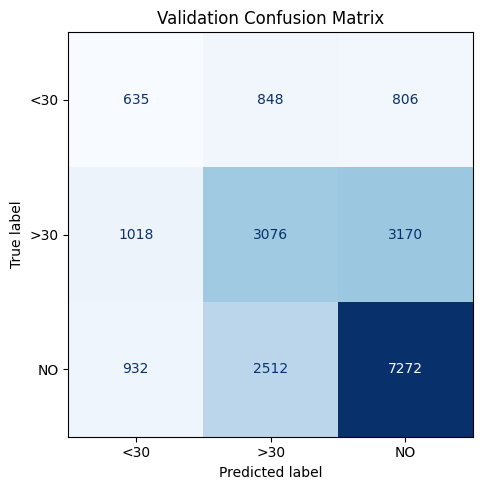

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Validation Confusion Matrix')
plt.tight_layout()

### Interpreting Feature Importance

The permutation-importance section below is computed on the original raw input columns, not on the one-hot-expanded columns. That means each bar answers: how much does model quality drop if this original feature is shuffled on the validation set?


In [30]:
feature_names = X_val.columns
perm = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring='f1_macro',
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
14,number_inpatient,0.057943,0.002318
4,discharge_disposition_id,0.028583,0.002780
13,number_emergency,0.007036,0.000994
18,number_diagnoses,0.005634,0.001442
7,payer_code,0.004015,0.000871
12,number_outpatient,0.003954,0.001131
5,admission_source_id,0.003924,0.000673
2,age,0.003107,0.000441
9,num_lab_procedures,0.002297,0.001123
3,admission_type_id,0.001936,0.000389


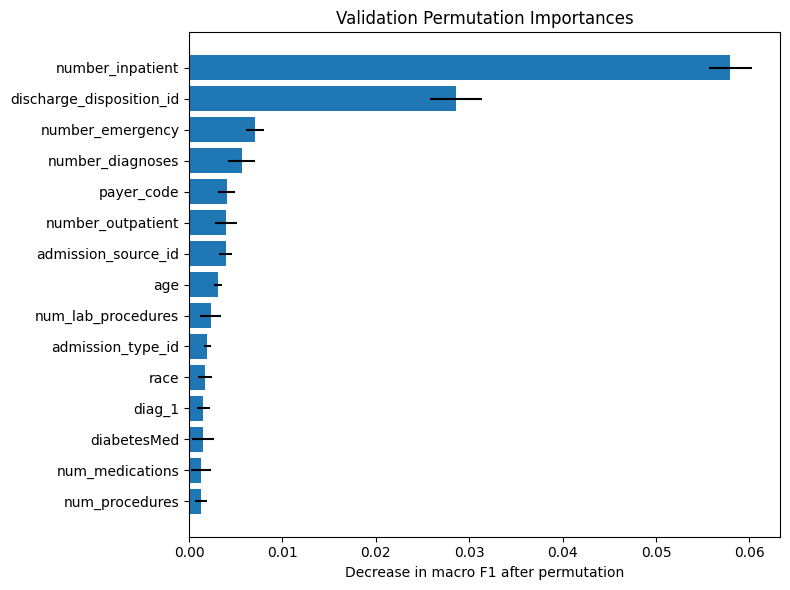

In [31]:
top_importance = importance_df.head(15).sort_values('importance_mean')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_importance['feature'], top_importance['importance_mean'], xerr=top_importance['importance_std'])
ax.set_title('Validation Permutation Importances')
ax.set_xlabel('Decrease in macro F1 after permutation')
plt.tight_layout()

## Final Test Evaluation

After hyperparameter selection is finished, refit the chosen model on the combined training and validation data and evaluate once on the held-out test set.

In [32]:
train_val_combined = pd.concat([train_raw, val_raw], ignore_index=True)
combined_specialty_keepers = set(
    train_val_combined['medical_specialty']
    .fillna('Missing')
    .value_counts()
    .loc[lambda s: s >= 500]
    .index
)
combined_constant_cols = [
    col for col in train_val_combined.columns
    if train_val_combined[col].nunique(dropna=False) == 1
]

train_val_df = clean_split(train_val_combined, combined_specialty_keepers, combined_constant_cols)
final_test_df = clean_split(test_raw, combined_specialty_keepers, combined_constant_cols)

X_train_val = train_val_df.drop(columns=[TARGET])
y_train_val = train_val_df[TARGET]
X_test_final = final_test_df.drop(columns=[TARGET])
y_test_final = final_test_df[TARGET]

final_numeric_cols = [col for col in COUNT_NUMERIC_COLS if col in X_train_val.columns]
final_categorical_cols = [col for col in X_train_val.columns if col not in final_numeric_cols]

final_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), final_numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), final_categorical_cols),
])

final_model = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=search.best_params_['model__n_estimators'],
        criterion=search.best_params_['model__criterion'],
        max_depth=search.best_params_['model__max_depth'],
        min_samples_split=search.best_params_['model__min_samples_split'],
        min_samples_leaf=search.best_params_['model__min_samples_leaf'],
        max_features=search.best_params_['model__max_features'],
        class_weight=search.best_params_['model__class_weight'],
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

final_model.fit(X_train_val, y_train_val)
test_pred = final_model.predict(X_test_final)

test_metrics = pd.Series({
    'accuracy': accuracy_score(y_test_final, test_pred),
    'macro_f1': f1_score(y_test_final, test_pred, average='macro'),
    'weighted_f1': f1_score(y_test_final, test_pred, average='weighted'),
    'oob_score_secondary': final_model.named_steps['model'].oob_score_,
})

validation_vs_test = pd.DataFrame({
    'validation': train_val_metrics['validation'],
    'test': test_metrics[['accuracy', 'macro_f1', 'weighted_f1']],
}).round(4)

display(test_metrics.round(4))
validation_vs_test


accuracy               0.5402
macro_f1               0.4531
weighted_f1            0.5393
oob_score_secondary    0.5378
dtype: float64

,validation,test
accuracy,0.5419,0.5402
macro_f1,0.4573,0.4531
weighted_f1,0.5404,0.5393


In [33]:
test_report_df = pd.DataFrame(classification_report(
    y_test_final,
    test_pred,
    zero_division=0,
    output_dict=True,
)).T

test_report_df.round(4)


,precision,recall,f1-score,support
<30,0.2331,0.2666,0.2487,2273.0000
>30,0.4775,0.4245,0.4495,7185.0000
NO,0.6473,0.6757,0.6612,10722.0000
accuracy,0.5402,0.5402,0.5402,0.5402
macro avg,0.4526,0.4556,0.4531,20180.0000
weighted avg,0.5402,0.5402,0.5393,20180.0000


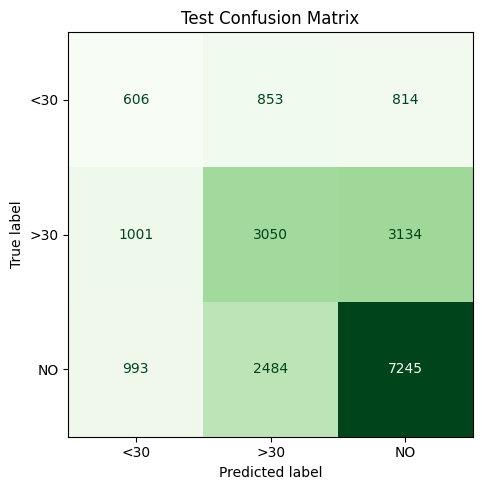

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_final, test_pred, ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Test Confusion Matrix')
plt.tight_layout()


,recall,f1-score
<30,0.2666,0.2487
>30,0.4245,0.4495
NO,0.6757,0.6612


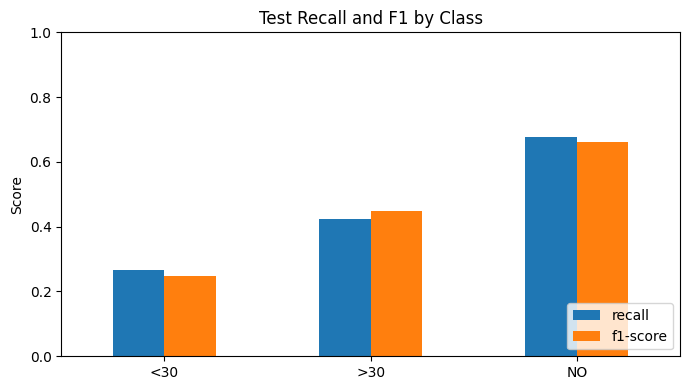

In [36]:
per_class_test = test_report_df.loc[['<30', '>30', 'NO'], ['recall', 'f1-score']].round(4)

fig, ax = plt.subplots(figsize=(7, 4))
per_class_test.plot(kind='bar', ax=ax)
ax.set_title('Test Recall and F1 by Class')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
per_class_test
